In [1]:
import os, json, random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(42)

Device: cuda


## 1. Tìm Đường dẫn Dữ liệu (Tự động)

In [2]:
def has_image_files(directory):
    """Kiểm tra thư mục có chứa file ảnh không (jpg/jpeg/png, mọi case)."""
    for ext in ['*.jpg', '*.JPG', '*.jpeg', '*.JPEG', '*.png', '*.PNG']:
        if any(True for _ in directory.glob(ext)):
            return True
    return False

def is_class_dir(directory, min_classes=5):
    """
    Kiểm tra một thư mục có phải là thư mục chứa các lớp (class folders) không.
    Điều kiện: có ít nhất min_classes thư mục con, mỗi thư mục con chứa ảnh.
    """
    subdirs = [d for d in directory.iterdir() if d.is_dir()]
    if len(subdirs) < min_classes:
        return False
    # Kiểm tra ít nhất 3 thư mục đầu có ảnh
    checks = [has_image_files(d) for d in subdirs[:3]]
    return sum(checks) >= 2

def find_plantvillage_root():
    """
    Tự động tìm thư mục PlantVillage trong mọi môi trường.
    Quét đệ quy tất cả thư mục trong /kaggle/input (Kaggle)
    hoặc các đường dẫn thông dụng (Colab / Local).
    """
    candidates = []

    # ── In cây thư mục để debug ──
    print('=== DEBUG: Cấu trúc /kaggle/input ===')
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        for p in sorted(kaggle_input.rglob('*')):
            depth = len(p.relative_to(kaggle_input).parts)
            if depth <= 3:  # chỉ in 3 cấp để không quá dài
                prefix = '  ' * (depth - 1)
                kind = '📁' if p.is_dir() else '🖼'
                print(f'{prefix}{kind} {p.name}')
    print('===================================')

    # ── 1. Kaggle: quét đệ quy /kaggle/input ──
    if kaggle_input.exists():
        # Duyệt tất cả thư mục con không giới hạn độ sâu
        for candidate in kaggle_input.rglob('*'):
            if candidate.is_dir() and is_class_dir(candidate, min_classes=5):
                n_subdirs = len([d for d in candidate.iterdir() if d.is_dir()])
                candidates.append(candidate)
                print(f'✓ Candidate: {candidate}  ({n_subdirs} lớp)')

    # ── 2. Colab / Local ──
    for p in [
        Path('/content/PlantVillage'),
        Path('/content/drive/MyDrive/PlantVillage'),
        Path('./data/plantvillage/PlantVillage'),
        Path('./data/PlantVillage'),
        Path('./PlantVillage'),
    ]:
        if p.exists() and is_class_dir(p, min_classes=5):
            candidates.append(p)
            print(f'✓ Local: {p}')

    if not candidates:
        raise FileNotFoundError(
            '❌ Không tìm thấy thư mục chứa các lớp PlantVillage!\n'
            'Kaggle: Vào "Add Input" → tìm "plantdisease" (emmarex/plantdisease) → Add.\n'
            'Local : kaggle datasets download -d emmarex/plantdisease\n'
            '        unzip plantdisease.zip -d ./data/plantvillage'
        )

    # Chọn candidate có nhiều lớp nhất (likely nhất là thư mục đúng)
    best = max(candidates, key=lambda p: len([d for d in p.iterdir() if d.is_dir()]))
    print(f'\n→ Dùng: {best}')
    return best


DATA_ROOT = find_plantvillage_root()
classes_raw = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f'\n✅ Data root: {DATA_ROOT}')
print(f'   Tổng số lớp: {len(classes_raw)}')
print(f'   Các lớp đầu: {classes_raw[:3]}...')

=== DEBUG: Cấu trúc /kaggle/input ===
📁 datasets
  📁 emmarex
    📁 plantdisease
✓ Candidate: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage  (15 lớp)
✓ Candidate: /kaggle/input/datasets/emmarex/plantdisease/plantvillage/PlantVillage  (15 lớp)

→ Dùng: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage

✅ Data root: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage
   Tổng số lớp: 15
   Các lớp đầu: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight']...


## 2. Phân tích Dữ liệu

Tổng số ảnh: 20638
Số lớp: 15
TB/lớp: 1376 | Min: 152 | Max: 3208


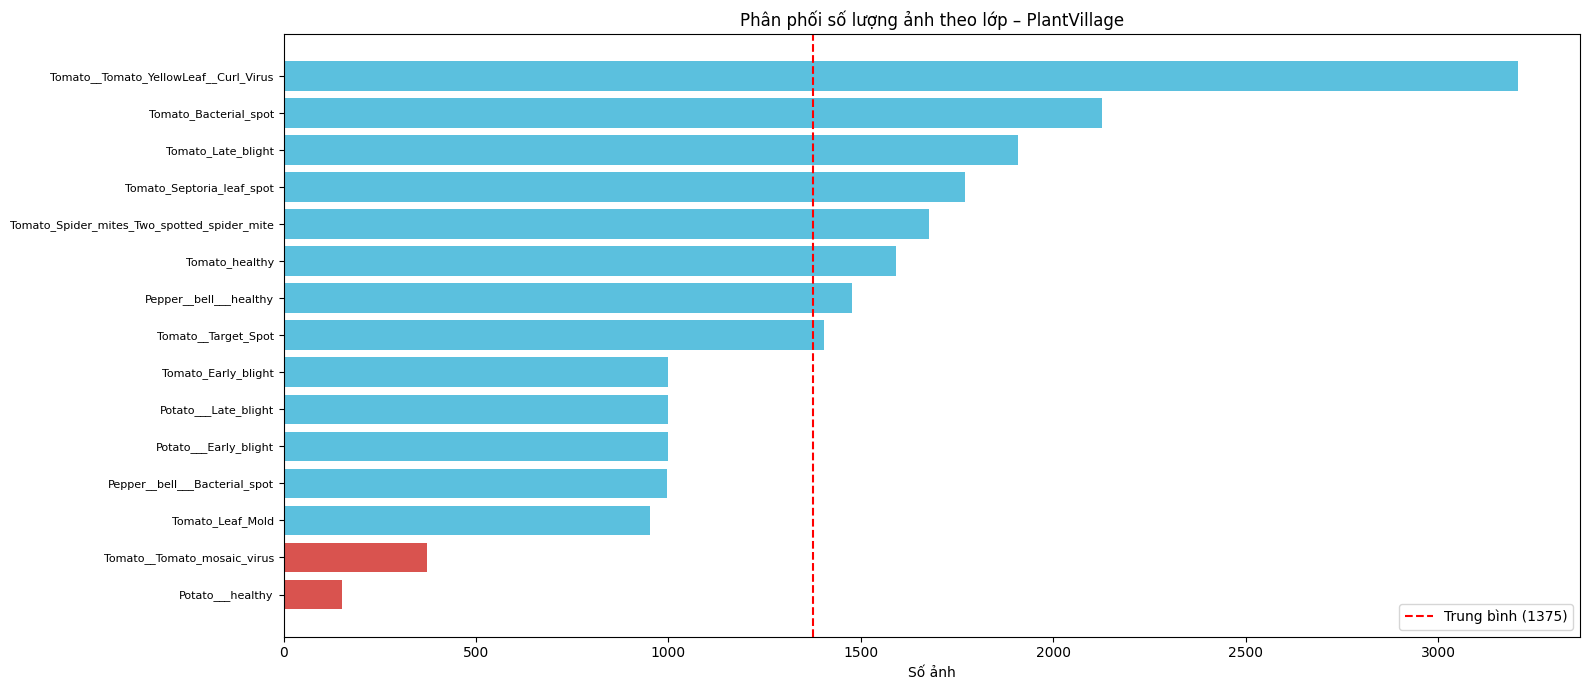

Lớp có ảnh ít (<500 ảnh, màu đỏ) cần WeightedSampler để cân bằng.


In [3]:
# Đếm số ảnh mỗi lớp
class_counts = {}
for cls_dir in sorted(DATA_ROOT.iterdir()):
    if cls_dir.is_dir():
        exts = ['*.jpg', '*.JPG', '*.jpeg', '*.png', '*.PNG']
        n = sum(len(list(cls_dir.glob(e))) for e in exts)
        class_counts[cls_dir.name] = n

total = sum(class_counts.values())
print(f'Tổng số ảnh: {total}')
print(f'Số lớp: {len(class_counts)}')
print(f'TB/lớp: {total/len(class_counts):.0f} | Min: {min(class_counts.values())} | Max: {max(class_counts.values())}')

# Biểu đồ phân phối
sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1]))
fig, ax = plt.subplots(figsize=(16, 7))
colors = ['#d9534f' if v < 500 else '#5bc0de' for v in sorted_counts.values()]
bars = ax.barh(list(sorted_counts.keys()), list(sorted_counts.values()), color=colors)
ax.axvline(total / len(class_counts), color='red', linestyle='--', label=f'Trung bình ({total//len(class_counts)})')
ax.set_xlabel('Số ảnh'); ax.set_title('Phân phối số lượng ảnh theo lớp – PlantVillage')
ax.legend(); ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()
print('Lớp có ảnh ít (<500 ảnh, màu đỏ) cần WeightedSampler để cân bằng.')

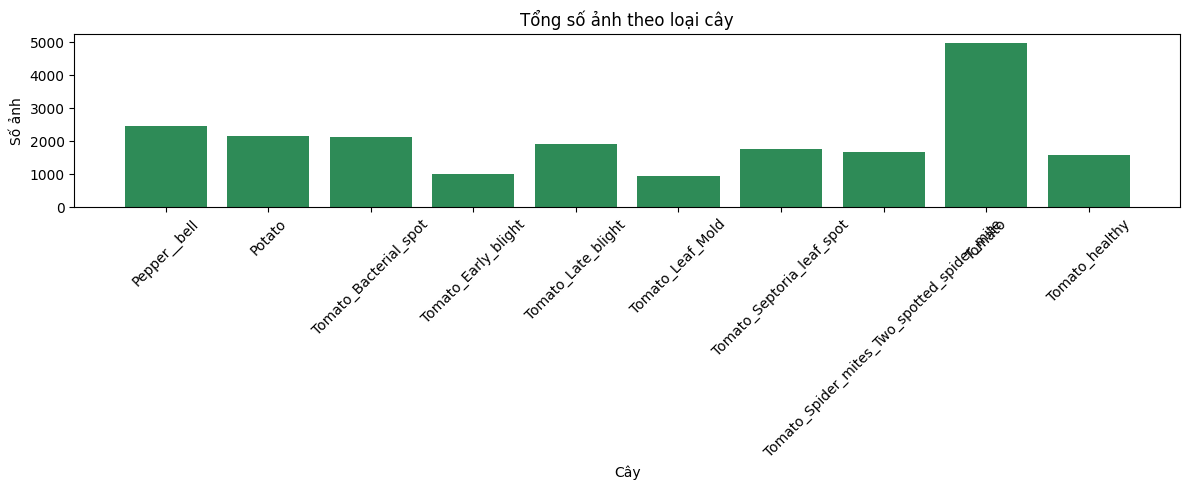

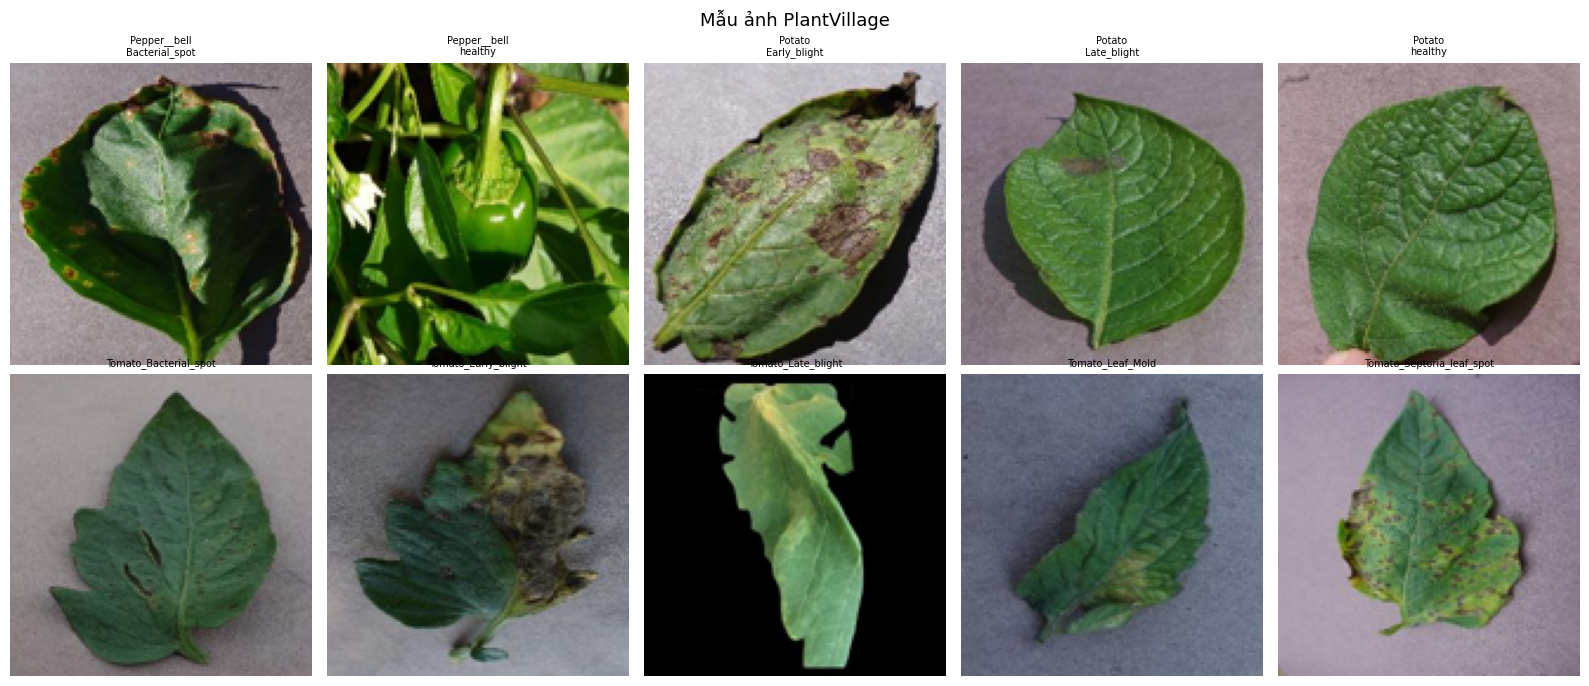

In [4]:
# Tự động detect separator (__ hay ___)
def split_class(name):
    """Tách tên lớp. Hỗ trợ cả '___' và '__'."""
    sep = '___' if '___' in name else '__'
    parts = name.split(sep)
    return parts[0], parts[-1] if len(parts) > 1 else ('Unknown', name)

# Phân tích theo loại cây
plant_stats = {}
for cls in class_counts:
    plant, _ = split_class(cls)
    plant_stats[plant] = plant_stats.get(plant, 0) + class_counts[cls]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(plant_stats.keys(), plant_stats.values(), color='seagreen')
ax.set_title('Tổng số ảnh theo loại cây'); ax.set_xlabel('Cây'); ax.set_ylabel('Số ảnh')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

# Hiển thị mẫu ảnh
from PIL import Image as PILImage
sample_classes = list(class_counts.keys())[:10]
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, cls in zip(axes.flatten(), sample_classes):
    imgs_in_cls = list((DATA_ROOT / cls).glob('*.jpg'))[:1] or list((DATA_ROOT / cls).glob('*.JPG'))[:1]
    if imgs_in_cls:
        ax.imshow(PILImage.open(imgs_in_cls[0]).resize((128, 128)))
    ax.set_title(cls.replace('___', '\n'), fontsize=7); ax.axis('off')
plt.suptitle('Mẫu ảnh PlantVillage', fontsize=13); plt.tight_layout(); plt.show()

## 3. Cân bằng Dữ liệu & Augmentation

In [5]:
IMG_SIZE   = 128
BATCH_SIZE = 64
VAL_RATIO  = 0.2

# Tính mean/std
_ds_raw = ImageFolder(str(DATA_ROOT),
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()]))
_ld = DataLoader(_ds_raw, batch_size=512, shuffle=False, num_workers=2)
_m = torch.zeros(3); _s = torch.zeros(3)
for imgs, _ in _ld:
    _m += imgs.mean([0,2,3]); _s += imgs.std([0,2,3])
MEAN = (_m / len(_ld)).tolist()
STD  = (_s / len(_ld)).tolist()
NUM_CLASSES = len(_ds_raw.classes)
print(f'Mean: {[round(v,4) for v in MEAN]}')
print(f'Std:  {[round(v,4) for v in STD]}')
print(f'Số lớp: {NUM_CLASSES}')

Mean: [0.4591, 0.4754, 0.4122]
Std:  [0.1766, 0.1526, 0.1916]
Số lớp: 15


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Train/Val split
full_ds = ImageFolder(str(DATA_ROOT))
n_total = len(full_ds)
n_val   = int(n_total * VAL_RATIO)
n_train = n_total - n_val
train_subset, val_subset = random_split(
    full_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset; self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform: img = self.transform(img)
        return img, label

train_ds = SubsetWithTransform(train_subset, train_transform)
val_ds   = SubsetWithTransform(val_subset,   val_transform)

# WeightedRandomSampler
train_labels   = [full_ds.targets[i] for i in train_subset.indices]
label_counts   = Counter(train_labels)
class_weights  = {k: 1.0 / v for k, v in label_counts.items()}
sample_weights = [class_weights[t] for t in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE*2, shuffle=False,  num_workers=2, pin_memory=True)

print(f'Train: {n_train} | Val: {n_val}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

# Kiểm tra cân bằng
sample_count = Counter()
for i, (_, lbl) in enumerate(train_loader):
    sample_count.update(lbl.tolist())
    if i >= 49: break
vals = list(sample_count.values())
print(f'Kiểm tra cân bằng (50 batch) – TB: {np.mean(vals):.1f}, Std: {np.std(vals):.1f} (std nhỏ = tốt)')

Train: 16511 | Val: 4127
Train batches: 258 | Val batches: 33
Kiểm tra cân bằng (50 batch) – TB: 213.3, Std: 11.1 (std nhỏ = tốt)


## 4. Xây dựng Mô hình (Residual CNN)

In [7]:
class ResBlock(nn.Module):
    """Mini residual block: 2 Conv + skip connection."""
    def __init__(self, in_c, out_c, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c,  out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
        )
        self.skip = nn.Sequential(
            nn.Conv2d(in_c, out_c, 1, bias=False),
            nn.BatchNorm2d(out_c)
        ) if in_c != out_c else nn.Identity()
        self.relu    = nn.ReLU(inplace=True)
        self.pool    = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        out = self.relu(self.conv(x) + self.skip(x))
        return self.dropout(self.pool(out))


class PlantVillage_CNN(nn.Module):
    """
    Residual CNN 5 khối cho PlantVillage (38 lớp).
    Input: 3×128×128 → 38 lớp
    128→64→32→16→8→4, sau đó GAP → FC
    """
    def __init__(self, num_classes=38, dropout_fc=0.4):
        super().__init__()
        self.features = nn.Sequential(
            ResBlock(3,   64,  dropout=0.05),
            ResBlock(64,  128, dropout=0.10),
            ResBlock(128, 256, dropout=0.20),
            ResBlock(256, 256, dropout=0.30),
            ResBlock(256, 512, dropout=0.35),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Dropout(dropout_fc),
            nn.Linear(256, num_classes),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))


model = PlantVillage_CNN(num_classes=NUM_CLASSES).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng params: {n_params:,}')
with torch.no_grad():
    out = model(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(device))
print(f'Output shape: {out.shape}  (mong muốn: [2, {NUM_CLASSES}])  ✓')

Tổng params: 6,177,295
Output shape: torch.Size([2, 15])  (mong muốn: [2, 15])  ✓


## 5. Huấn luyện

In [8]:
NUM_EPOCHS = 60

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-5
)

train_losses, train_accs = [], []
val_losses,   val_accs   = [], []
best_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──
    model.train()
    r_loss = correct = total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        r_loss  += loss.item()
        _, pred  = out.max(1)
        correct += pred.eq(labels).sum().item()
        total   += labels.size(0)
    scheduler.step()

    t_loss = r_loss / len(train_loader)
    t_acc  = 100 * correct / total
    train_losses.append(t_loss); train_accs.append(t_acc)

    # ── Validate ──
    model.eval()
    v_loss = v_correct = v_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out    = model(imgs)
            v_loss += criterion(out, labels).item()
            _, pred = out.max(1)
            v_correct += pred.eq(labels).sum().item()
            v_total   += labels.size(0)

    v_loss /= len(val_loader)
    v_acc   = 100 * v_correct / v_total
    val_losses.append(v_loss); val_accs.append(v_acc)

    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model.state_dict(), 'best_plantvillage.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
              f'Train {t_loss:.4f}/{t_acc:.1f}% | '
              f'Val {v_loss:.4f}/{v_acc:.1f}%  '
              f'lr={optimizer.param_groups[0]["lr"]:.6f}')

print(f'\n✅ Best Val Accuracy: {best_acc:.2f}%')

Epoch   1/60 | Train 2.4924/23.6% | Val 1.8565/47.1%  lr=0.000495
Epoch   5/60 | Train 1.5913/59.8% | Val 1.2843/71.1%  lr=0.000378
Epoch  10/60 | Train 1.2411/74.8% | Val 0.8854/88.5%  lr=0.000133
Epoch  15/60 | Train 1.1151/80.3% | Val 0.8343/91.0%  lr=0.000500
Epoch  20/60 | Train 1.1074/80.6% | Val 0.8018/91.4%  lr=0.000467
Epoch  25/60 | Train 0.9928/85.4% | Val 0.7647/93.1%  lr=0.000378
Epoch  30/60 | Train 0.9250/87.9% | Val 0.7033/95.5%  lr=0.000255
Epoch  35/60 | Train 0.8652/90.1% | Val 0.6890/95.7%  lr=0.000133
Epoch  40/60 | Train 0.8280/91.7% | Val 0.6585/97.1%  lr=0.000043
Epoch  45/60 | Train 0.8142/92.3% | Val 0.6470/97.5%  lr=0.000500
Epoch  50/60 | Train 0.8866/89.5% | Val 0.6794/96.5%  lr=0.000492
Epoch  55/60 | Train 0.8424/91.0% | Val 0.6566/96.7%  lr=0.000467
Epoch  60/60 | Train 0.8082/92.2% | Val 0.6727/96.3%  lr=0.000428

✅ Best Val Accuracy: 97.53%


## 6. Trực quan & Đánh giá

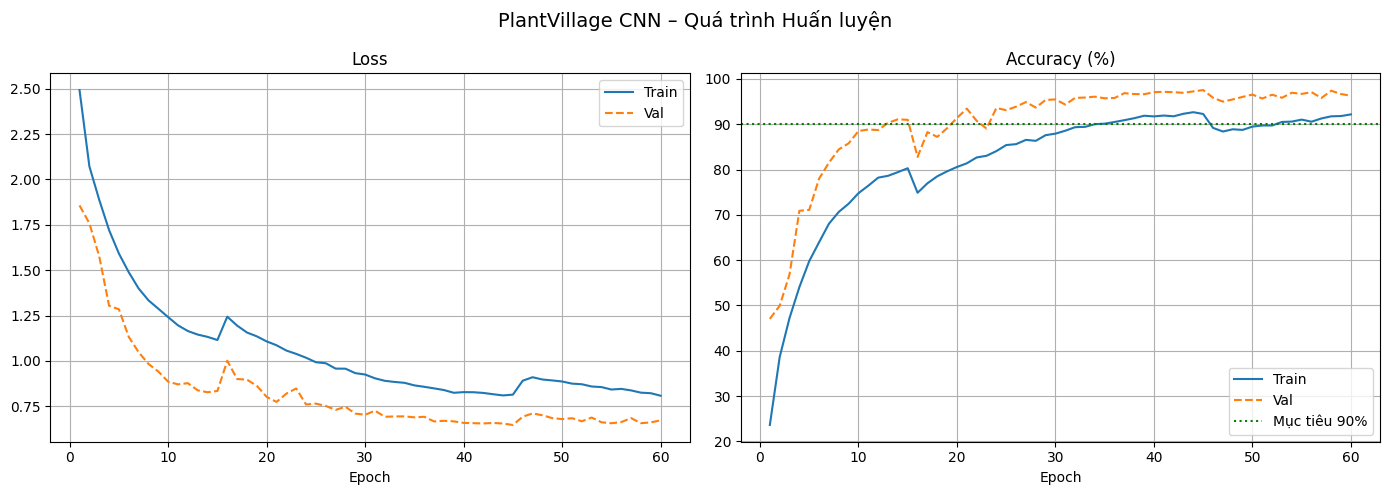

Train Acc cuối: 92.16%
Val   Acc cuối: 96.27%
Best  Val  Acc: 97.53%
Gap: -4.11%


In [9]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, train_losses, label='Train'); axes[0].plot(epochs, val_losses, label='Val', linestyle='--')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(epochs, train_accs, label='Train'); axes[1].plot(epochs, val_accs, label='Val', linestyle='--')
axes[1].axhline(90, color='green', linestyle=':', label='Mục tiêu 90%')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('PlantVillage CNN – Quá trình Huấn luyện', fontsize=14)
plt.tight_layout(); plt.show()

print(f'Train Acc cuối: {train_accs[-1]:.2f}%')
print(f'Val   Acc cuối: {val_accs[-1]:.2f}%')
print(f'Best  Val  Acc: {best_acc:.2f}%')
print(f'Gap: {train_accs[-1] - val_accs[-1]:.2f}%')

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load('best_plantvillage.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        _, pred = model(imgs.to(device)).max(1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=full_ds.classes))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.99      0.99       188
                     Pepper__bell___healthy       1.00      0.99      0.99       307
                      Potato___Early_blight       1.00      0.97      0.98       214
                       Potato___Late_blight       0.98      0.95      0.96       211
                           Potato___healthy       0.97      1.00      0.98        30
                      Tomato_Bacterial_spot       0.99      0.97      0.98       448
                        Tomato_Early_blight       0.89      0.96      0.93       196
                         Tomato_Late_blight       0.96      0.94      0.95       361
                           Tomato_Leaf_Mold       0.99      0.99      0.99       191
                  Tomato_Septoria_leaf_spot       0.96      0.99      0.97       348
Tomato_Spider_mites_Two_spotted_spider_mite       0.97      0.98

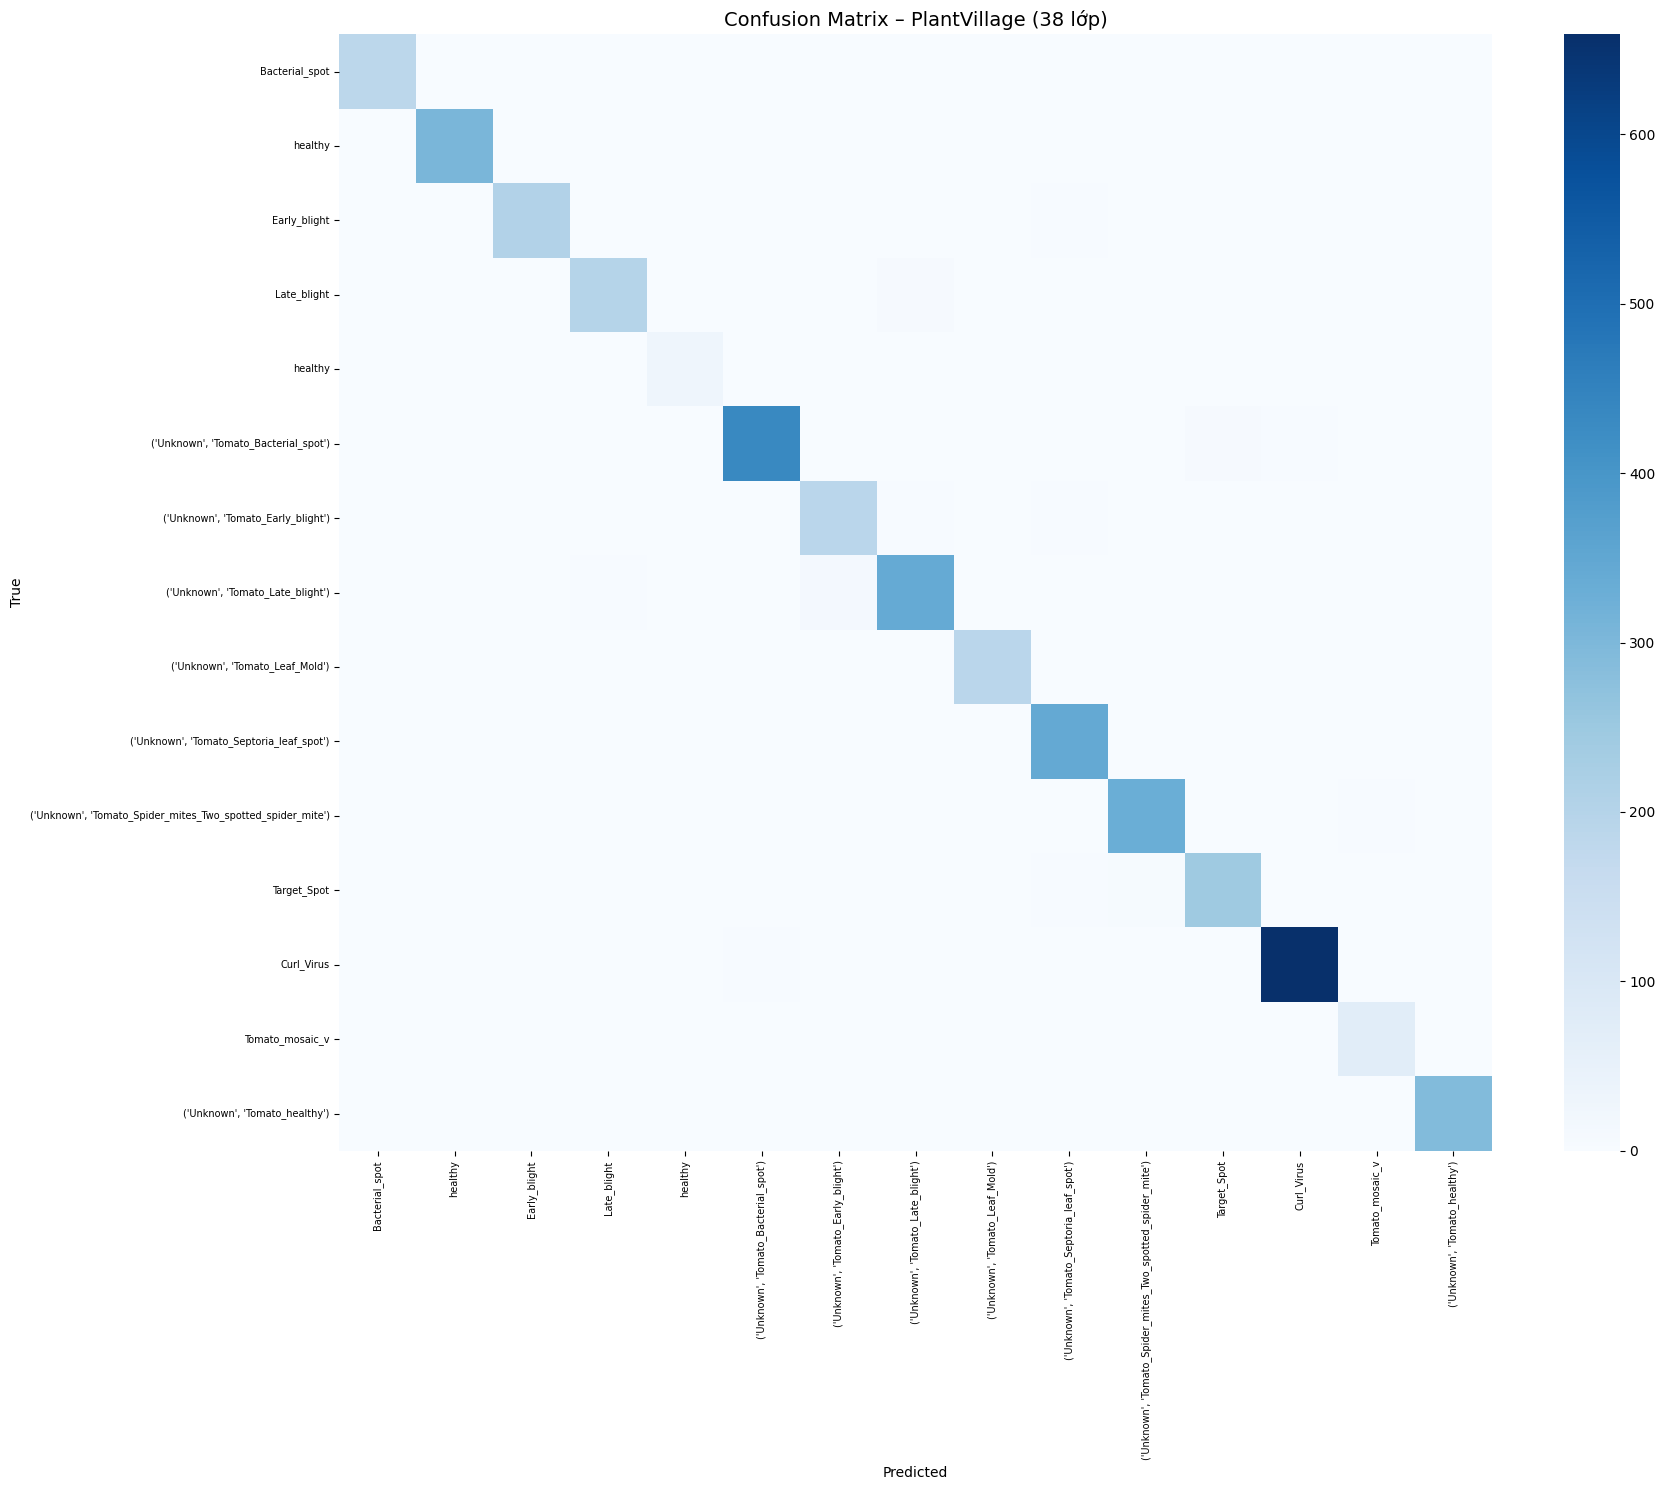

In [11]:
# Confusion matrix 38×38
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=[split_class(c)[1][:15] for c in full_ds.classes],
            yticklabels=[split_class(c)[1][:15] for c in full_ds.classes], ax=ax)
ax.set_title('Confusion Matrix – PlantVillage (38 lớp)', fontsize=14)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout(); plt.show()

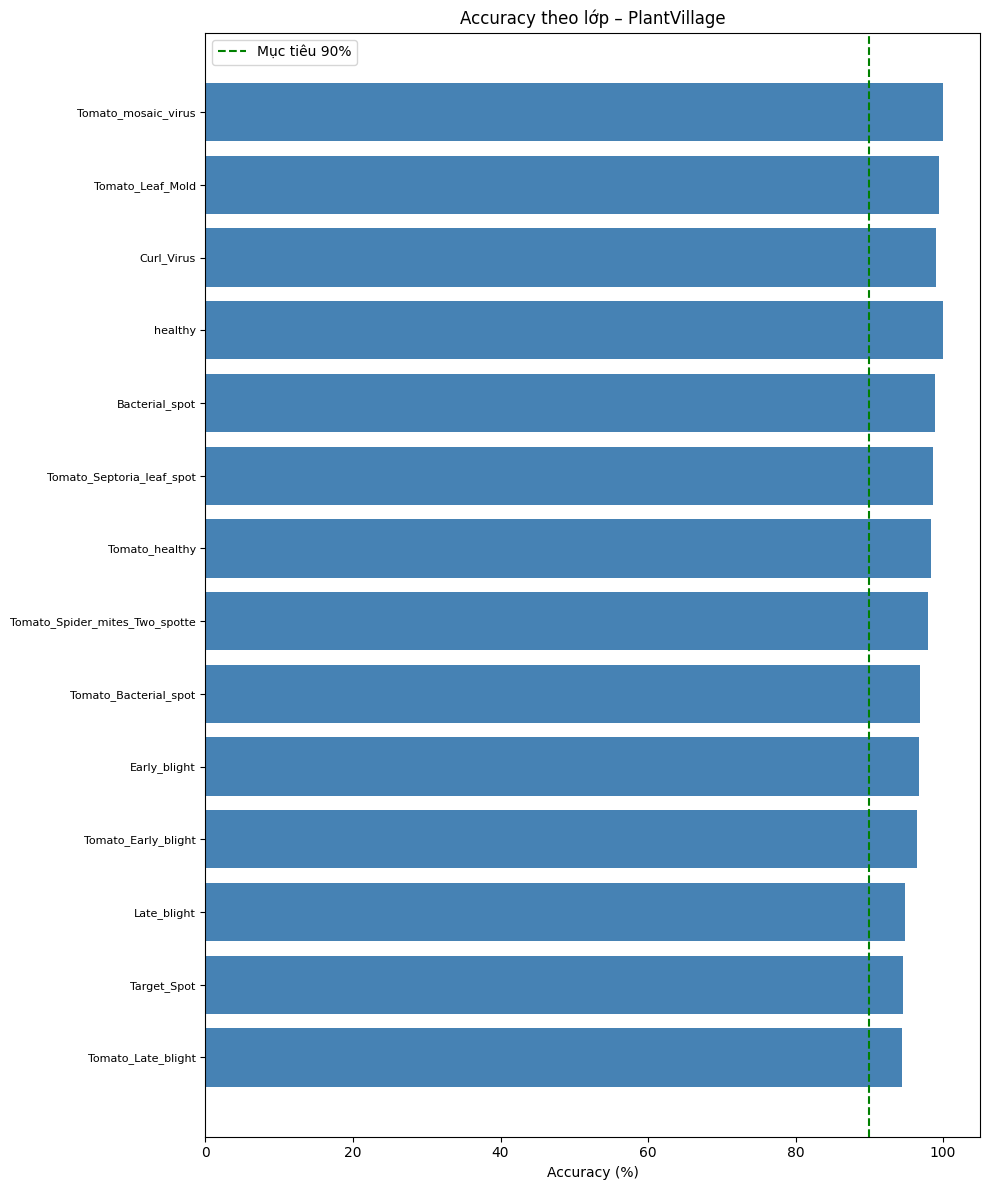

Top 5 lớp khó nhất:
  Tomato_Late_blight                           : 94.5%
  Tomato__Target_Spot                          : 94.6%
  Potato___Late_blight                         : 94.8%
  Tomato_Early_blight                          : 96.4%
  Potato___Early_blight                        : 96.7%

Top 5 lớp tốt nhất:
  Pepper__bell___healthy                       : 99.0%
  Tomato__Tomato_YellowLeaf__Curl_Virus        : 99.1%
  Tomato_Leaf_Mold                             : 99.5%
  Potato___healthy                             : 100.0%
  Tomato__Tomato_mosaic_virus                  : 100.0%


In [12]:
# Accuracy từng lớp
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
sorted_idx = np.argsort(per_class_acc)

# Lấy tên ngắn gọn cho từng lớp
def get_short_name(cls_name, max_len=30):
    for sep in ['___', '__']:
        if sep in cls_name:
            return cls_name.split(sep)[-1][:max_len]
    return cls_name[:max_len]

short_labels = [get_short_name(full_ds.classes[i]) for i in sorted_idx]

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['red' if per_class_acc[i] < 85 else 'steelblue' for i in sorted_idx]
ax.barh(short_labels, per_class_acc[sorted_idx], color=colors)
ax.axvline(90, color='green', linestyle='--', label='Mục tiêu 90%')
ax.set_xlabel('Accuracy (%)'); ax.set_title('Accuracy theo lớp – PlantVillage')
ax.legend(); ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

print('Top 5 lớp khó nhất:')
for i in sorted_idx[:5]:
    print(f'  {full_ds.classes[i]:45s}: {per_class_acc[i]:.1f}%')
print('\nTop 5 lớp tốt nhất:')
for i in sorted_idx[-5:]:
    print(f'  {full_ds.classes[i]:45s}: {per_class_acc[i]:.1f}%')

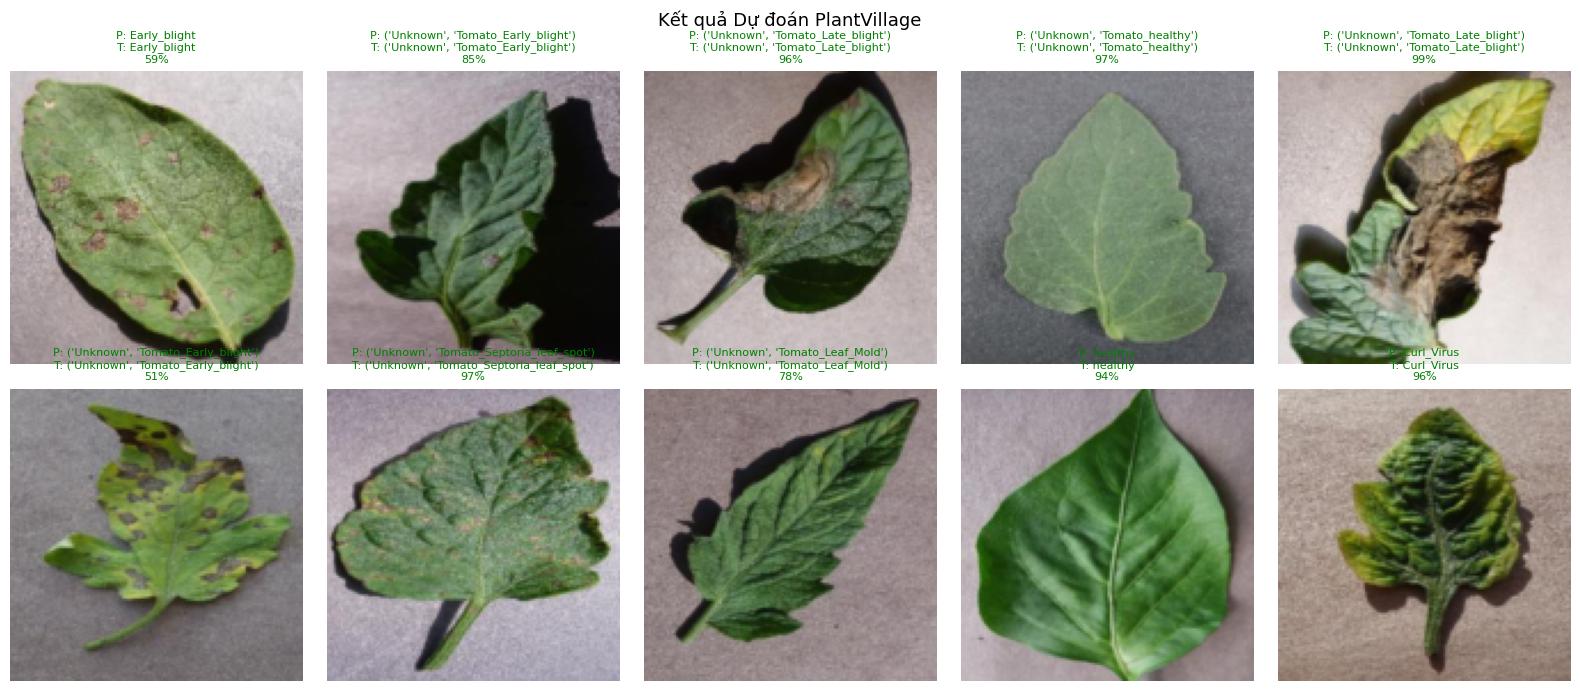

In [13]:
# Dự đoán mẫu
imgs_b, labels_b = next(iter(val_loader))
imgs_b = imgs_b.to(device)
mean_t = torch.tensor(MEAN).view(3,1,1); std_t = torch.tensor(STD).view(3,1,1)
with torch.no_grad():
    probs = torch.softmax(model(imgs_b), dim=1)
    confs, preds = probs.max(1)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axes.flatten()):
    img_show = (imgs_b[i].cpu() * std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()
    ax.imshow(img_show)
    pred_name = split_class(full_ds.classes[preds[i]])[1]
    true_name = split_class(full_ds.classes[labels_b[i]])[1]
    color = 'green' if preds[i].item() == labels_b[i].item() else 'red'
    ax.set_title(f'P: {pred_name[:18]}\nT: {true_name[:18]}\n{confs[i]:.0%}',
                 color=color, fontsize=8)
    ax.axis('off')
plt.suptitle('Kết quả Dự đoán PlantVillage', fontsize=13)
plt.tight_layout(); plt.show()